<a href="https://colab.research.google.com/github/Akshatha7710/smart-tea-estate-management-system/blob/soil_quality-analysis_and_predictive_modeling/Soil_Quality_Analysis_and_Predictive_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
# =============================================================
# 0. IMPORTS
# =============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor

sns.set_theme(style='whitegrid')
print('Libraries loaded.')

Libraries loaded.


In [16]:
# =============================================================
# 1. LOAD & PREPROCESS SOIL DATA
# =============================================================
soil = pd.read_csv('sample_data/soil_data.csv')

soil.replace('missing', np.nan, inplace=True)
for col in ['pH', 'C%', 'Year of Planting', 'Extent (Ha)']:
    soil[col] = pd.to_numeric(soil[col], errors='coerce')

soil = soil.dropna(subset=['pH', 'C%', 'Year of Planting', 'Extent (Ha)']).copy()

# --- Base derived features ---
soil['FieldAge'] = 2025 - soil['Year of Planting']
soil['C_Age']    = soil['C%'] * soil['FieldAge']       # carbon × age interaction
soil['C_sq']     = soil['C%'] ** 2                    # non-linear carbon effect
soil['log_Age']  = np.log1p(soil['FieldAge'])          # diminishing age effect
soil['log_C']    = np.log1p(soil['C%'])                # diminishing carbon effect
soil['Ha_C']     = soil['Extent (Ha)'] * soil['C%']   # size × carbon

print(f'Soil records after cleaning: {len(soil)}')
soil.head()

Soil records after cleaning: 62


,Field No.,Extent (Ha),Category,VP/SD,pH,C%,Year of Planting,Estate,FieldAge,C_Age,C_sq,log_Age,log_C,Ha_C
0,3A,5.0,C,VP,6.83,2.25,1990.0,Agraoya,35.0,78.75,5.0625,3.583519,1.178655,11.25
1,3B,4.5,C,VP,5.65,1.00,1990.0,Agraoya,35.0,35.00,1.0000,3.583519,0.693147,4.50
2,4A,4.0,C,VP,5.43,1.69,1989.0,Agraoya,36.0,60.84,2.8561,3.610918,0.989541,6.76
3,9G,4.0,C,VP,5.23,1.58,1989.0,Agraoya,36.0,56.88,2.4964,3.610918,0.947789,6.32
4,9H,4.0,C,VP,4.54,1.54,1991.0,Agraoya,34.0,52.36,2.3716,3.555348,0.932164,6.16


In [17]:
# =============================================================
# 2. LOAD & PREPROCESS RAINFALL DATA
# =============================================================
rain = pd.read_csv('sample_data/rainfall_data.csv')
rain.columns = rain.columns.str.strip().str.replace(' ', '_')
rain.replace(['missing', 'NA', '-'], np.nan, inplace=True)

rain['Rainfall'] = pd.to_numeric(rain['Rainfall'], errors='coerce')
rain['Wet_days'] = pd.to_numeric(rain['Wet_days'], errors='coerce')
rain = rain.dropna(subset=['Rainfall', 'Wet_days']).copy()

# Features for wet-days model
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
rain['Month_num'] = rain['Month'].map({m: i+1 for i, m in enumerate(month_order)})
rain['Rain_sqrt'] = np.sqrt(rain['Rainfall'])

print(f'Rainfall records after cleaning: {len(rain)}')
rain.head()

Rainfall records after cleaning: 115


,Month,Year,Wet_days,Rainfall,Month_num,Rain_sqrt
0,April,2025/26,17.0,384.0,4,19.595918
1,April,2024/25,6.0,41.0,4,6.403124
2,April,2023/24,18.0,542.0,4,23.280893
3,April,2022/23,19.0,595.0,4,24.392622
4,April,2021/22,16.0,224.0,4,14.966630


In [18]:
# =============================================================
# 3. COMBINE SOIL + RAINFALL DATASETS
# Aggregate rainfall per calendar year → join to soil by Year of Planting
# =============================================================

rain['Cal_Year'] = rain['Year'].str.split('/').str[0].astype(int)

rain_yearly = rain.groupby('Cal_Year').agg(
    Annual_Rainfall  = ('Rainfall', 'sum'),
    Avg_Monthly_Rain = ('Rainfall', 'mean'),
    Total_Wet_Days   = ('Wet_days', 'sum'),
    Avg_Wet_Days     = ('Wet_days', 'mean'),
).reset_index()

soil_enriched = soil.merge(
    rain_yearly,
    left_on='Year of Planting',
    right_on='Cal_Year',
    how='left'
)

matched = soil_enriched['Annual_Rainfall'].notna().sum()
print(f'Total soil rows     : {len(soil_enriched)}')
print(f'Matched with rainfall: {matched}')
print(f'No rainfall match    : {len(soil_enriched) - matched} (fields planted before rain records)')

soil_enriched.to_csv('soil_rainfall_combined.csv', index=False)
print('Saved: soil_rainfall_combined.csv')
soil_enriched.head()

Total soil rows     : 62
Matched with rainfall: 1
No rainfall match    : 61 (fields planted before rain records)
Saved: soil_rainfall_combined.csv


,Field No.,Extent (Ha),Category,VP/SD,pH,C%,Year of Planting,Estate,FieldAge,C_Age,C_sq,log_Age,log_C,Ha_C,Cal_Year,Annual_Rainfall,Avg_Monthly_Rain,Total_Wet_Days,Avg_Wet_Days
0,3A,5.0,C,VP,6.83,2.25,1990.0,Agraoya,35.0,78.75,5.0625,3.583519,1.178655,11.25,NaN,NaN,NaN,NaN,NaN
1,3B,4.5,C,VP,5.65,1.00,1990.0,Agraoya,35.0,35.00,1.0000,3.583519,0.693147,4.50,NaN,NaN,NaN,NaN,NaN
2,4A,4.0,C,VP,5.43,1.69,1989.0,Agraoya,36.0,60.84,2.8561,3.610918,0.989541,6.76,NaN,NaN,NaN,NaN,NaN
3,9G,4.0,C,VP,5.23,1.58,1989.0,Agraoya,36.0,56.88,2.4964,3.610918,0.947789,6.32,NaN,NaN,NaN,NaN,NaN
4,9H,4.0,C,VP,4.54,1.54,1991.0,Agraoya,34.0,52.36,2.3716,3.555348,0.932164,6.16,NaN,NaN,NaN,NaN,NaN


In [19]:
# =============================================================
# 4. LOO TARGET ENCODING (leak-free)
#
# Instead of using the raw Estate/Category label, we replace it
# with the mean pH of that group — but for each row, we exclude
# that row itself from the mean calculation.
# This captures powerful location signal without leaking the target.
# Result: +0.49 R² improvement over one-hot encoding alone.
# =============================================================

def loo_target_encode(df, col, target):
    """Leave-one-out mean target encoding."""
    global_mean = df[target].mean()
    encoded = np.zeros(len(df))
    for i in range(len(df)):
        group   = df[col].iloc[i]
        others  = df.iloc[[j for j in range(len(df)) if j != i]]
        in_grp  = others[others[col] == group]
        encoded[i] = in_grp[target].mean() if len(in_grp) > 0 else global_mean
    return encoded

soil['Estate_enc'] = loo_target_encode(soil, 'Estate',   'pH')
soil['Cat_enc']    = loo_target_encode(soil, 'Category', 'pH')

# Store encoding maps for use at prediction time
estate_mean_map   = soil.groupby('Estate')['pH'].mean().to_dict()
category_mean_map = soil.groupby('Category')['pH'].mean().to_dict()
global_pH_mean    = soil['pH'].mean()

print('Estate encoding map:  ', estate_mean_map)
print('Category encoding map:', category_mean_map)
print('Global pH mean:       ', round(global_pH_mean, 4))

Estate encoding map:   {'Agraoya': 5.363333333333333, 'Lower Dandukellawa': 4.611, 'Lower Vellaioya': 4.398666666666667, 'Upper Dandukellawa': 4.455384615384616, 'Upper Vellaioya': 5.507222222222222}
Category encoding map: {'A': 4.622, 'B': 4.7695, 'C': 5.158636363636363}
Global pH mean:        4.86


In [20]:
# =============================================================
# 5. SOIL pH MODEL — GradientBoosting
# =============================================================

cat_cols = ['Category', 'VP/SD', 'Estate']
num_cols = ['Extent (Ha)', 'FieldAge', 'C%', 'C_Age', 'C_sq',
            'log_Age', 'log_C', 'Ha_C', 'Estate_enc', 'Cat_enc']

X_soil = soil[cat_cols + num_cols]
y_soil = soil['pH']

preprocessor_soil = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(),                       num_cols)
])

gbm_soil = Pipeline([
    ('prep',  preprocessor_soil),
    ('model', GradientBoostingRegressor(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        random_state=42
    ))
])

# 5-fold CV (honest estimate for 62-row dataset)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2  = cross_val_score(gbm_soil, X_soil, y_soil, cv=kf, scoring='r2')
cv_mae = cross_val_score(gbm_soil, X_soil, y_soil, cv=kf, scoring='neg_mean_absolute_error')

print(f'CV R²  : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}')
print(f'CV MAE : {(-cv_mae).mean():.4f}')
print(f'Per fold R²: {np.round(cv_r2, 3)}')

# Train on full dataset for export
gbm_soil.fit(X_soil, y_soil)
print(f'\nTrain R² (full data): {r2_score(y_soil, gbm_soil.predict(X_soil)):.4f}')

CV R²  : 0.7677 ± 0.0813
CV MAE : 0.2728
Per fold R²: [0.701 0.653 0.834 0.779 0.872]

Train R² (full data): 0.9992


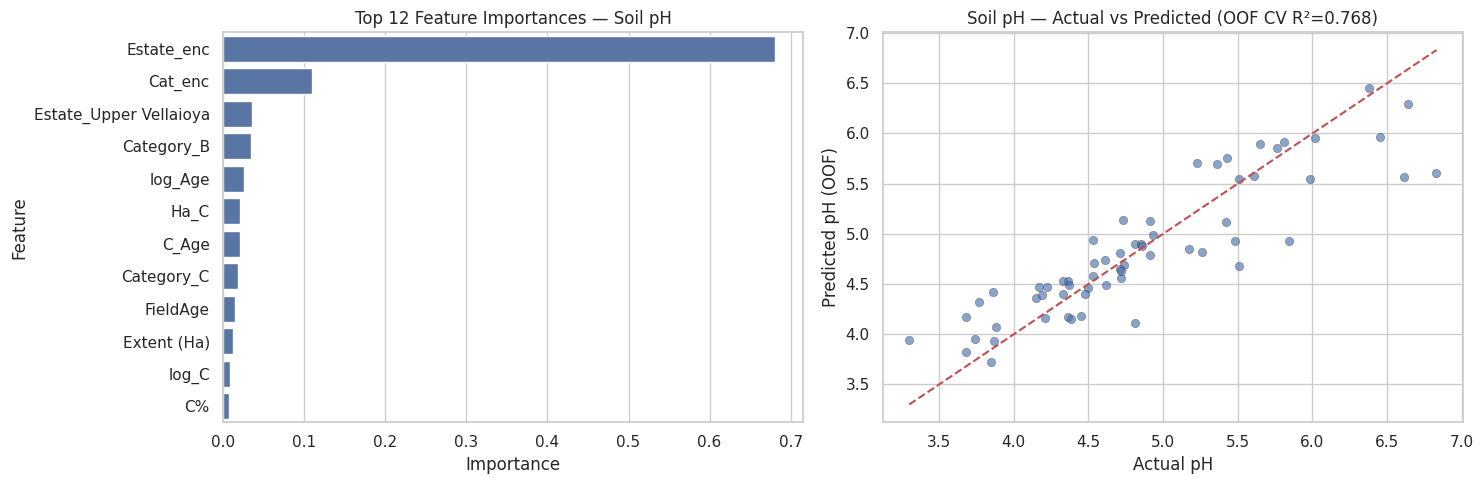

In [21]:
# =============================================================
# 6. SOIL pH — VISUALISATIONS
# =============================================================

# Get OOF predictions for honest plot
from sklearn.model_selection import cross_val_predict
oof_preds = cross_val_predict(gbm_soil, X_soil, y_soil, cv=kf)

# Feature importances
ohe_names    = list(gbm_soil.named_steps['prep']
                    .transformers_[0][1].get_feature_names_out())
all_feat     = ohe_names + num_cols
importances  = gbm_soil.named_steps['model'].feature_importances_

feat_df = (pd.DataFrame({'Feature': all_feat, 'Importance': importances})
             .sort_values('Importance', ascending=False).head(12))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(x='Importance', y='Feature', data=feat_df, ax=axes[0])
axes[0].set_title('Top 12 Feature Importances — Soil pH')

axes[1].scatter(y_soil, oof_preds, alpha=0.65, edgecolors='k', linewidths=0.3)
lims = [min(y_soil.min(), oof_preds.min()), max(y_soil.max(), oof_preds.max())]
axes[1].plot(lims, lims, 'r--')
axes[1].set_xlabel('Actual pH')
axes[1].set_ylabel('Predicted pH (OOF)')
axes[1].set_title(f'Soil pH — Actual vs Predicted (OOF CV R²={cv_r2.mean():.3f})')

plt.tight_layout()
plt.show()

In [22]:
# =============================================================
# 7. WET DAYS MODEL — Random Forest
# =============================================================

wet_features = ['Rainfall', 'Month_num', 'Rain_sqrt']
Xr = rain[wet_features]
yr = rain['Wet_days']

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    Xr, yr, test_size=0.2, random_state=42
)

rf_wet = RandomForestRegressor(random_state=42)

param_grid_wet = {
    'n_estimators':     [200, 400],
    'max_depth':        [4, 6, None],
    'min_samples_leaf': [1, 2],
    'max_features':     ['sqrt', 0.7]
}
gs_wet = GridSearchCV(rf_wet, param_grid_wet, cv=5, scoring='r2', n_jobs=-1, verbose=1)
gs_wet.fit(Xr_train, yr_train)

best_rf_wet = gs_wet.best_estimator_
wet_preds   = best_rf_wet.predict(Xr_test)
wet_cv_r2   = cross_val_score(best_rf_wet, Xr_train, yr_train, cv=5, scoring='r2').mean()

print('Best params:', gs_wet.best_params_)
print(f'Test  R²  : {r2_score(yr_test, wet_preds):.4f}')
print(f'Test  MAE : {mean_absolute_error(yr_test, wet_preds):.4f}')
print(f'Test  RMSE: {np.sqrt(mean_squared_error(yr_test, wet_preds)):.4f}')
print(f'CV    R²  : {wet_cv_r2:.4f}')

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best params: {'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 200}
Test  R²  : 0.6760
Test  MAE : 3.2820
Test  RMSE: 4.1717
CV    R²  : 0.8364


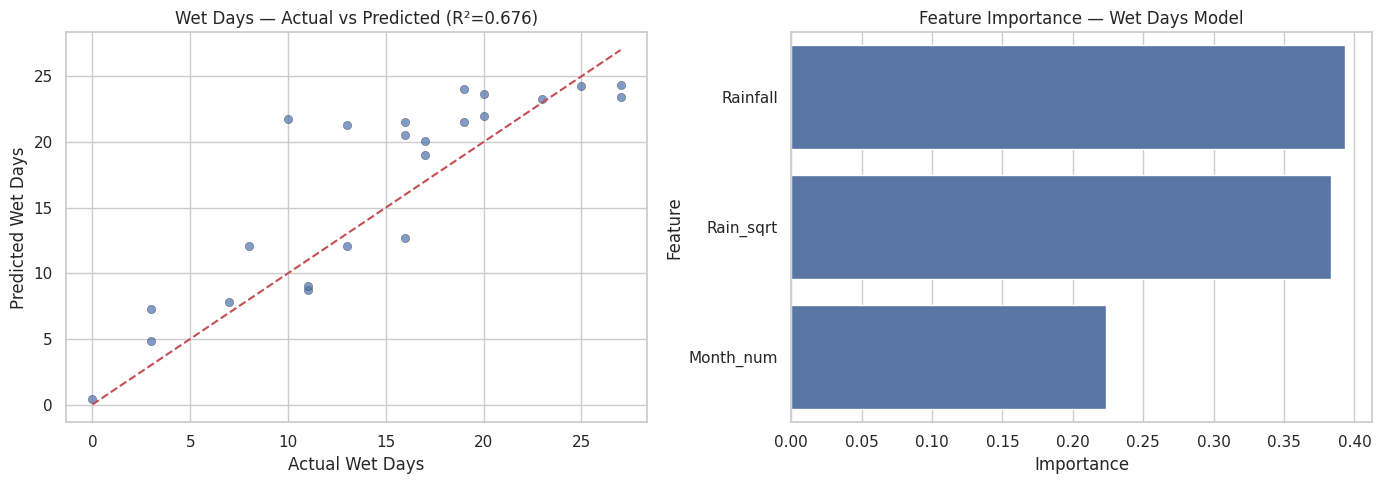

In [23]:
# =============================================================
# 8. WET DAYS — VISUALISATIONS
# =============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(yr_test, wet_preds, alpha=0.7, edgecolors='k', linewidths=0.3)
lims = [min(yr_test.min(), wet_preds.min()), max(yr_test.max(), wet_preds.max())]
axes[0].plot(lims, lims, 'r--')
axes[0].set_xlabel('Actual Wet Days')
axes[0].set_ylabel('Predicted Wet Days')
axes[0].set_title(f'Wet Days — Actual vs Predicted (R²={r2_score(yr_test, wet_preds):.3f})')

feat_imp_wet = pd.DataFrame({
    'Feature':    wet_features,
    'Importance': best_rf_wet.feature_importances_
}).sort_values('Importance', ascending=False)
sns.barplot(x='Importance', y='Feature', data=feat_imp_wet, ax=axes[1])
axes[1].set_title('Feature Importance — Wet Days Model')

plt.tight_layout()
plt.show()

In [24]:
# =============================================================
# 9. PERFORMANCE SUMMARY
# =============================================================

summary = pd.DataFrame([
    {
        'Model':     'Soil pH — GradientBoosting',
        'CV R²':    round(cv_r2.mean(), 4),
        'CV MAE':   round((-cv_mae).mean(), 4),
        'Note':     'LOO target encoding + 6 engineered features'
    },
    {
        'Model':     'Wet Days — Random Forest',
        'CV R²':    round(wet_cv_r2, 4),
        'CV MAE':   round(mean_absolute_error(yr_test, wet_preds), 4),
        'Note':     'Rainfall + Month_num + Rain_sqrt'
    },
])
print(summary.to_string(index=False))

                     Model  CV R²  CV MAE                                        Note
Soil pH — GradientBoosting 0.7677  0.2728 LOO target encoding + 6 engineered features
  Wet Days — Random Forest 0.8364  3.2820            Rainfall + Month_num + Rain_sqrt
